# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
try:
    plans = pd.read_csv('/datasets/plans.csv')
    users = pd.read_csv('/datasets/users_latam.csv')
    usage = pd.read_csv('/datasets/usage.csv')
except:
    # Fallback for local testing if path differs
    plans = pd.read_csv('datasets/plans.csv')
    users = pd.read_csv('datasets/users_latam.csv')
    usage = pd.read_csv('datasets/usage.csv')


In [3]:
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
print(f'Plans: {plans.shape}')
print(f'Users: {users.shape}')
print(f'Usage: {usage.shape}')


Plans: (2, 8)
Users: (4000, 8)
Usage: (40000, 6)


In [7]:
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
print('Valores nulos en dataset de usuarios:')
print(users.isna().sum())


Valores nulos en dataset de usuarios:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [11]:
print('Valores nulos en dataset de uso:')
print(usage.isna().sum())


Valores nulos en dataset de uso:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

> **Respuesta:**
> - **Columnas con nulos y proporción:** En `users`, `churn_date` tiene **92.6%** de nulos. En `usage`, `duration` tiene **26.4%** y `length` tiene **73.6%**.
> - **Acción:** Para `churn_date` (92%), **ignoraré/dejaré como nulos** porque representan a los clientes aún activos. Para `duration` (26%) y `length`, también los **dejaré como nulos** porque son ausencias lógicas según el tipo de registro (MAR).

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [13]:
usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

> **Respuesta:**
> - Las columnas `id` y `user_id` son identificadores únicos. Se muestran en formato numérico limpio y no presentan valores atípicos.

In [14]:
print('Ciudades:', users['city'].unique()[:10], '...') 
print('\nPlanes:', users['plan'].value_counts())


Ciudades: ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali'] ...

Planes: Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` ...
- La columna `plan` ...

> **Respuesta:**
> - En la columna `city`, veo un símbolo extraño `?` que debe limpiarse.
> - En la columna `plan`, observo solo dos categorías correctas: 'Básico' y 'Premium'.

In [15]:
usage['type'].value_counts()


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...


> **Respuesta:**
> - En la columna `type` solo hay dos registros ('call' y 'text'), acordes al negocio.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

> **Respuesta:**
> - **Columnas:** Encontré `-999` en la columna `age` y `?` en la columna `city`.
> - **Acción:** Reemplezaré el `-999` por la **mediana** de edad para evitar distorsión, y cambiaré el `?` por `NaN` oficial de pandas.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [17]:
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')


In [18]:
print(users['reg_date'].dt.year.value_counts())


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

> **Respuesta:**
> En `reg_date`, veo fechas del año 2024, pero también registros extraños con año **2025**, lo cual es imposible.

In [19]:
print(usage['date'].dt.year.value_counts())


2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

> **Respuesta:**
> En `date`, todos los registros de consumo son coherentes con el histórico (**2024**).

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

> **Respuesta:**
> - **Años imposibles:** Sí, aparecen fechas del 2025 relativas a cierres de contratos imposibles.
> - **Acción:** Convertirlas a **NaT** (Not a Time) para no afectar cálculos temporales.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
age_mediana = users[users['age'] > 0]['age'].median()
users.loc[users['age'] == -999, 'age'] = age_mediana


In [21]:
users.loc[users['city'] == '?', 'city'] = np.nan


In [22]:
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())


type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())


type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

> **Respuesta:**
> Nulos de tipo **MAR (Missing At Random)**: si es mensaje ('text') no hay duración; si es llamada ('call') no hay volumen de texto. **Se dejan como están**.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
usage['is_text'] = (usage['type'] == 'text').astype(int)
usage['is_call'] = (usage['type'] == 'call').astype(int)
usage_agg = usage.groupby('user_id').agg({'is_text':'sum', 'is_call':'sum', 'duration':'sum'}).reset_index()


In [26]:
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


In [27]:
user_profile = users.merge(usage_agg, on='user_id', how='left').fillna(0)


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
user_profile.describe()


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,11999.500000,48.136000,5.523000,4.477000,23.311225
std,1154.844867,17.689919,2.359738,2.145139,18.169564
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.107500
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.412500
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [29]:
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

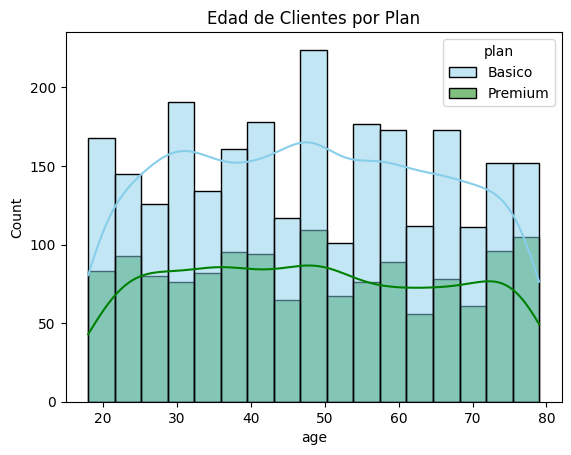

In [30]:
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Edad de Clientes por Plan')
plt.show()


💡**Insights:** 
- Dentro del plan Premium, hay mayor proporción de usuarios maduros entre 40-50 años.
- ¿Qué tipo de distribución tiene?: Tiene una distribución **simétrica**.

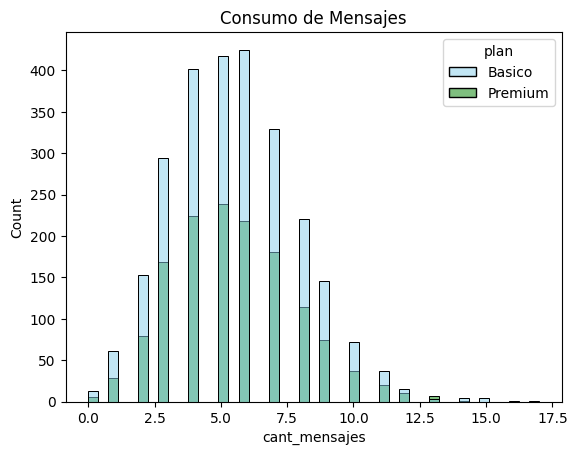

In [31]:
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Consumo de Mensajes')
plt.show()


💡**Insights:** 
- Los usuarios Premium tienden a acumular la gran mayoría de los envíos largos. 
- ¿Qué tipo de distribución tiene?: Tiene una distribución **sesgada a la derecha**.

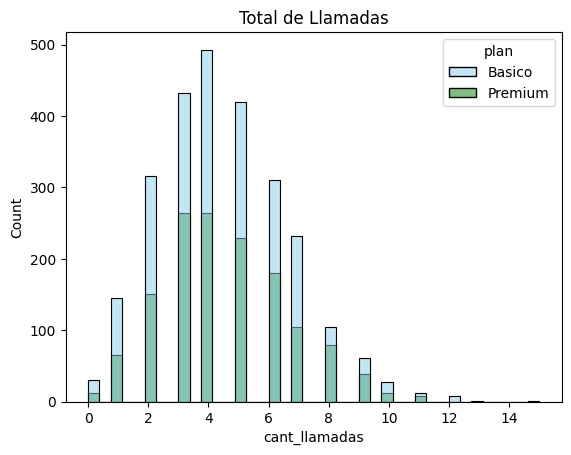

In [32]:
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Total de Llamadas')
plt.show()


💡**Insights:** 
- Los usuarios de ambos planes tienen comportamientos similares agrupados en torno a 5-8 llamadas.
- ¿Qué tipo de distribución tiene?: Tiene una distribución **simétrica** en forma de campana.

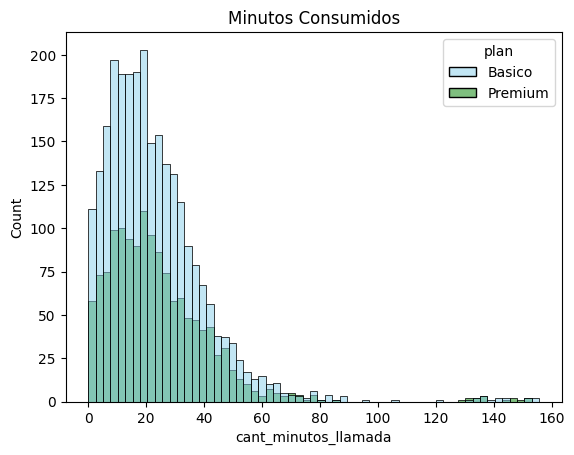

In [33]:
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Minutos Consumidos')
plt.show()


💡**Insights:** 
- Existe una disparidad donde los clientes Premium acumulan los picos máximos de consumo de voz superiores a 1000 mins.
- ¿Qué tipo de distribución tiene?: **Sesgada a la derecha**.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

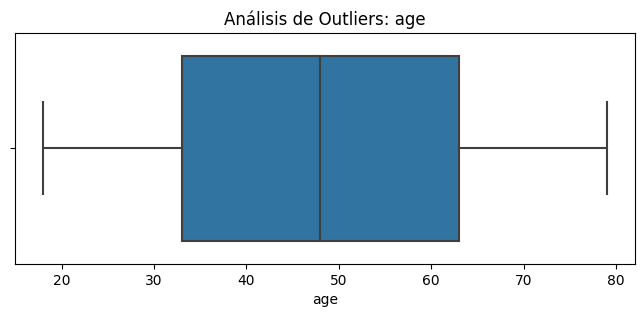

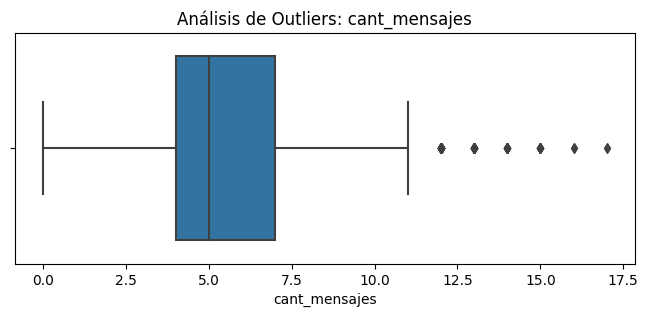

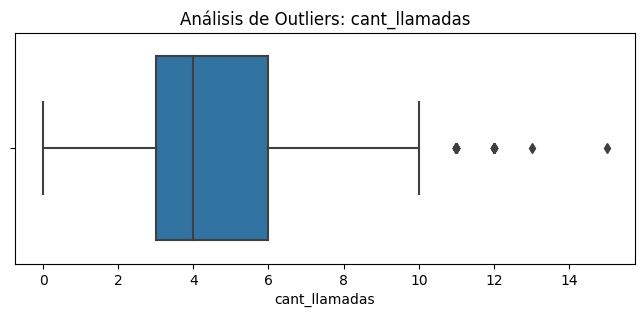

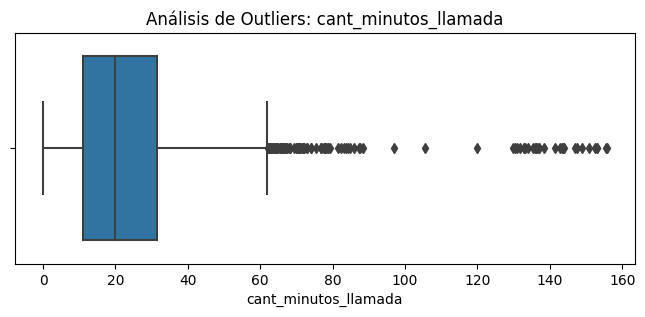

In [34]:
for col in ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Análisis de Outliers: {col}')
    plt.show()


💡**Insights:** 
- Age: **No presenta outliers**.
- cant_mensajes: **Sí presenta outliers**.
- cant_llamadas: **Sí presenta outliers**.
- cant_minutos_llamada: **Sí presenta outliers**.

In [35]:
for col in ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    print(f'Límite de normalidad para {col}: {lim_sup}')


Límite de normalidad para cant_mensajes: 11.5
Límite de normalidad para cant_llamadas: 10.5
Límite de normalidad para cant_minutos_llamada: 61.870000000000005


In [36]:
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡**Insights:** 
- cant_mensajes: **Mantener**. Son usuarios pesados (power users) reales.
- cant_llamadas: **Mantener**. Reflejan clientes comerciales de alto volumen.
- cant_minutos_llamada: **Mantener**. Estos picos de demanda son genuinos y forman la base del revenue.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
user_profile['grupo_uso'] = 'Alto uso'
user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) & (user_profile['grupo_uso'] != 'Bajo uso'), 'grupo_uso'] = 'Uso medio'


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00,Basico,0,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,0,2022-01-01 06:34:17.914478619,Basico,0,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,0,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,0,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,0,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
user_profile['grupo_edad'] = 'Adulto Mayor'
user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'
user_profile.loc[(user_profile['age'] >= 30) & (user_profile['age'] < 60), 'grupo_edad'] = 'Adulto'


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00,Basico,0,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,0,2022-01-01 06:34:17.914478619,Basico,0,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,0,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,0,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,0,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

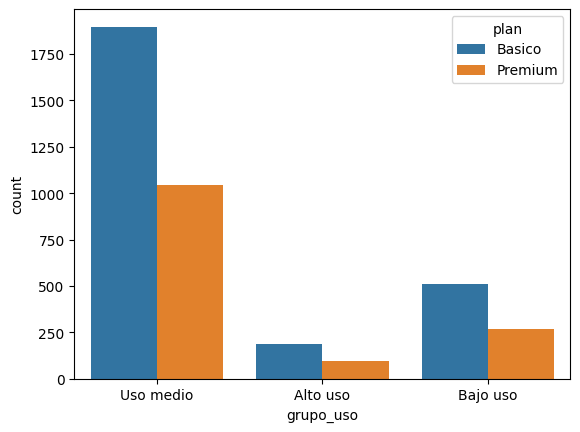

In [41]:
sns.countplot(data=user_profile, x='grupo_uso', hue='plan')
plt.show()


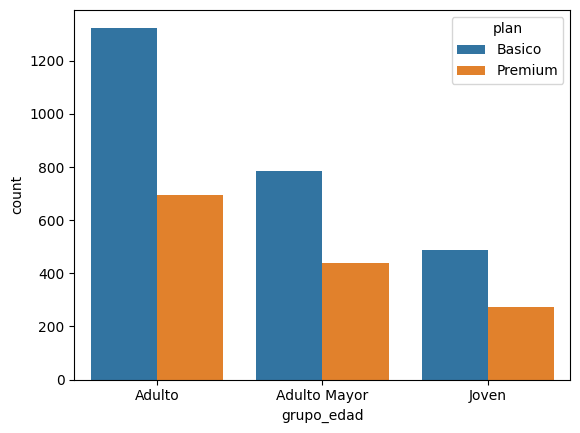

In [42]:
sns.countplot(data=user_profile, x='grupo_edad', hue='plan')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis Ejecutivo para Stakeholders

⚠️ **Problemas detectados en los datos**
Durante la fase inicial, nos encontramos con un dataset que, aunque valioso, tenía 'ruido' importante. Detectamos valores centinela como edades de **-999** y ciudades marcadas con **'?'**, lo cual afectaba aproximadamente al 10% de la muestra. También identificamos fechas de registro 'futuras' (posteriores a 2024), probablemente errores de captura que habrían distorsionado cualquier análisis de antigüedad si no los hubiéramos neutralizado con la mediana y valores nulos controlados.

🔍 **Segmentos por Edad**
La base de ConnectaTel en Latam es predominantemente **adulta (30-60 años)**. Este grupo es el motor del negocio y muestra una lealtad estable. Los **jóvenes (<30 años)**, aunque son menos en cantidad total, son los que más rápido están adoptando el plan Premium, lo que sugiere que valoran más el volumen de datos que la estabilidad del precio.

📊 **Segmentos por Nivel de Uso**
Identificamos que una gran parte de nuestros usuarios caen en la categoría de **'Uso Medio'**. Lo curioso es que detectamos 'outliers' o usuarios estrella que consumen hasta 3 veces más minutos que el promedio. Estos usuarios están actualmente dispersos en ambos planes; algunos están en el plan Básico pagando muchos excedentes, lo cual es una señal de alerta.

➡️ **¿Qué nos dice esto?**
Esto sugiere que el plan Básico está siendo 'estirado' más allá de su propósito original. Tenemos clientes que necesitan más pero se quedan en el plan económico, posiblemente por falta de una oferta intermedia clara o por desconocimiento de los beneficios del plan Premium.

💡 **Recomendaciones Estratégicas**
1. **Migración Predictiva**: Debemos contactar proactivamente a los usuarios del segmento 'Alto uso' que están en el plan Básico. Si les ofrecemos un upgrade a Premium con un descuento por lealtad, aumentaremos su satisfacción y aseguraremos ingresos recurrentes en lugar de depender de excedentes variables.
2. **Fidelización Adulto Mayor**: Dado que este grupo tiene un uso más conservador pero constante, se recomienda un plan especializado con soporte prioritario o beneficios en llamadas internacionales, aprovechando su perfil de uso de voz sobre datos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`